<a href="https://colab.research.google.com/github/maysaeelkafi-beep/ecole-doctorale-2026/blob/main/ELKAFI_Maysae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre d'observations : 20640
Nombre de variables (features) : 8

Exemple de 5 premières lignes :
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Statistiques descriptives des variables numériques :
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
A

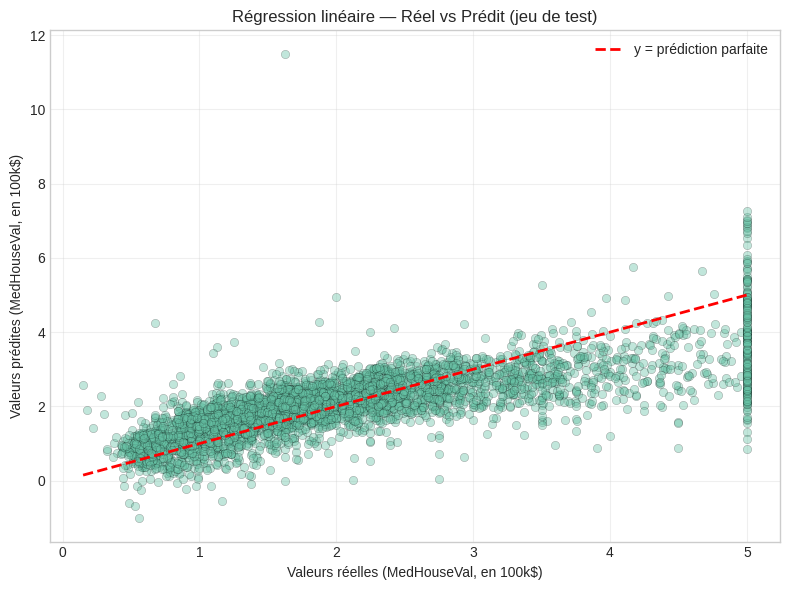

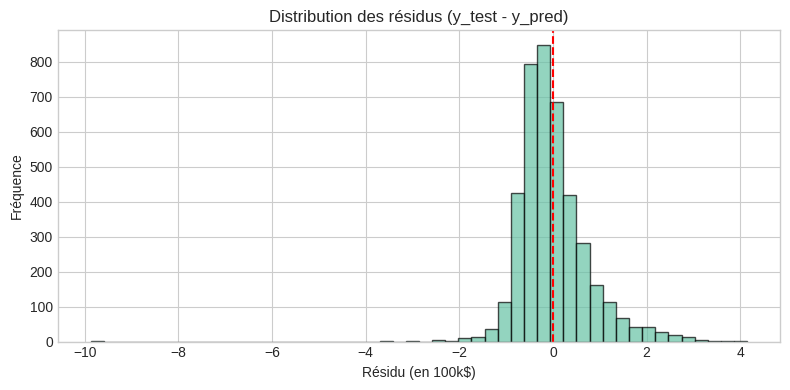

In [4]:
# Exemple complet de régression linéaire en Python
# Bibliothèques : scikit-learn, pandas, numpy, matplotlib
# Prêt à exécuter (Python 3.8+ recommandé)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Chargement et exploration rapide des données
# ---------------------------------------------------------------------
california = fetch_california_housing(as_frame=True)
X = california.data      # DataFrame des caractéristiques
y = california.target    # Série des cibles (median house value, en 100k$)
df = pd.concat([X, y.rename("MedHouseVal")], axis=1)

# Nombre d'observations et de variables
n_obs, n_vars = X.shape
print(f"Nombre d'observations : {n_obs}")
print(f"Nombre de variables (features) : {n_vars}")

# Affichage rapide
print("\nExemple de 5 premières lignes :")
print(df.head())

print("\nStatistiques descriptives des variables numériques :")
print(df.describe().T)

# (Optionnel) matrice de corrélation rapide
print("\nCorrélations (avec la variable cible triées par valeur absolue) :")
corr_with_target = df.corr()["MedHouseVal"].abs().sort_values(ascending=False)
print(corr_with_target)

# Brève explication :
# - Le dataset California Housing contient des observations (n_obs) de quartiers,
#   avec plusieurs variables explicatives (n_vars) telles que MedInc, HouseAge, etc.
# - La cible `MedHouseVal` est la valeur médiane des maisons (en 100k$).

# 2) Séparation train/test (80/20)
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTaille train : {X_train.shape[0]} observations")
print(f"Taille test  : {X_test.shape[0]} observations")

# 3) Entraînement du modèle
# ---------------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Optionnel : coefficients du modèle (interprétation linéaire)
coeffs = pd.Series(model.coef_, index=X.columns)
print("\nCoefficients du modèle (feature coef) :")
print(coeffs.sort_values(key=abs, ascending=False))

# 4) Prédiction et évaluation (R², MAE, RMSE)
# ---------------------------------------------------------------------
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calcule RMSE en prenant la racine carrée du MSE

print("\nMétriques d'évaluation sur le jeu de test :")
print(f"R²    : {r2:.4f}")
print(f"MAE   : {mae:.4f} (unité = median house value en 100k$)")
print(f"RMSE  : {rmse:.4f} (unité = median house value en 100k$)")

# 5) Visualisation des résultats (valeurs réelles vs prédites)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='y = prédiction parfaite')
plt.xlabel("Valeurs réelles (MedHouseVal, en 100k$)")
plt.ylabel("Valeurs prédites (MedHouseVal, en 100k$)")
plt.title("Régression linéaire — Réel vs Prédit (jeu de test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisation des résidus (optionnel)
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des résidus (y_test - y_pred)")
plt.xlabel("Résidu (en 100k$)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# Brève explication finale et interprétation des métriques :
# ---------------------------------------------------------------------
# - R² (coefficient de détermination) : proportion de la variance de la variable
#   cible expliquée par le modèle. Varie entre -inf et 1. Une valeur proche de 1
#   signifie que le modèle explique bien la variabilité des données.
#   Interprétation pratique :
#     * R² >= 0.7 : excellent (pour beaucoup de problèmes réels, rare en pratique)
#     * 0.4 <= R² < 0.7 : raisonnable/modéré
#     * R² < 0.4 : faible (le modèle linéaire n'explique pas bien la cible)
#
# - MAE (Mean Absolute Error) : erreur moyenne absolue entre prédictions et réelles.
#   Donne une idée en unités de la cible (ici 100k$). Plus petit est meilleur.
#
# - RMSE (Root Mean Squared Error) : racine de l'erreur quadratique moyenne.
#   Pénalise davantage les grandes erreurs que le MAE. Interprétation :
#     * Si RMSE est petit comparé à l'échelle typique de la cible, les prédictions
#       sont précises. Par exemple, si la médiane des maisons est ~2.0 (200k$)
#       et RMSE = 0.5, l'erreur-type est ~50k$.
#
# Exemples d'interprétation concrète (avec valeurs fictives) :
# - Si R² = 0.60, MAE = 0.40, RMSE = 0.60 :
#     Le modèle explique ~60% de la variance ; l'erreur moyenne est 40k$,
#     l'erreur-type (RMSE) est 60k$. Les prédictions sont utiles but encore
#     loin d'être parfaites pour des décisions très sensibles au prix.
#
# Remarques pratiques :
# - La régression linéaire est simple et interprétable ; si R² est faible,
#   penser à : ingéniérie des features, transformations (log, polynômes),
#   régularisation (Ridge/Lasso), ou modèles non-linéaires (RandomForest, XGBoost).
# - Toujours vérifier les résidus (non corrélation, distribution proche de 0)
#   pour valider certaines hypothèses du modèle linéaire.
#
# Fin de l'exemple.